In [274]:
# Import all necessaty libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display as ipd
import scipy.signal as signal

In [169]:
# Load and hear the speech signal
name_signal, sr = librosa.load("wav_files/name.wav", sr=16000)
ipd.Audio("wav_files/name.wav")

In [170]:
print(name_signal.size)
print(np.max(name_signal))
print(np.argmax(name_signal))

63744
0.87576294
40818


In [171]:
# duration in seconds of 1 sample
sample_duration = 1 / sr
duration = 1 / sr * len(name_signal)
print(f"One sample lasts for {sample_duration:6f} seconds")
print(f"The audio lasts for {duration} seconds")

One sample lasts for 0.000063 seconds
The audio lasts for 3.984 seconds


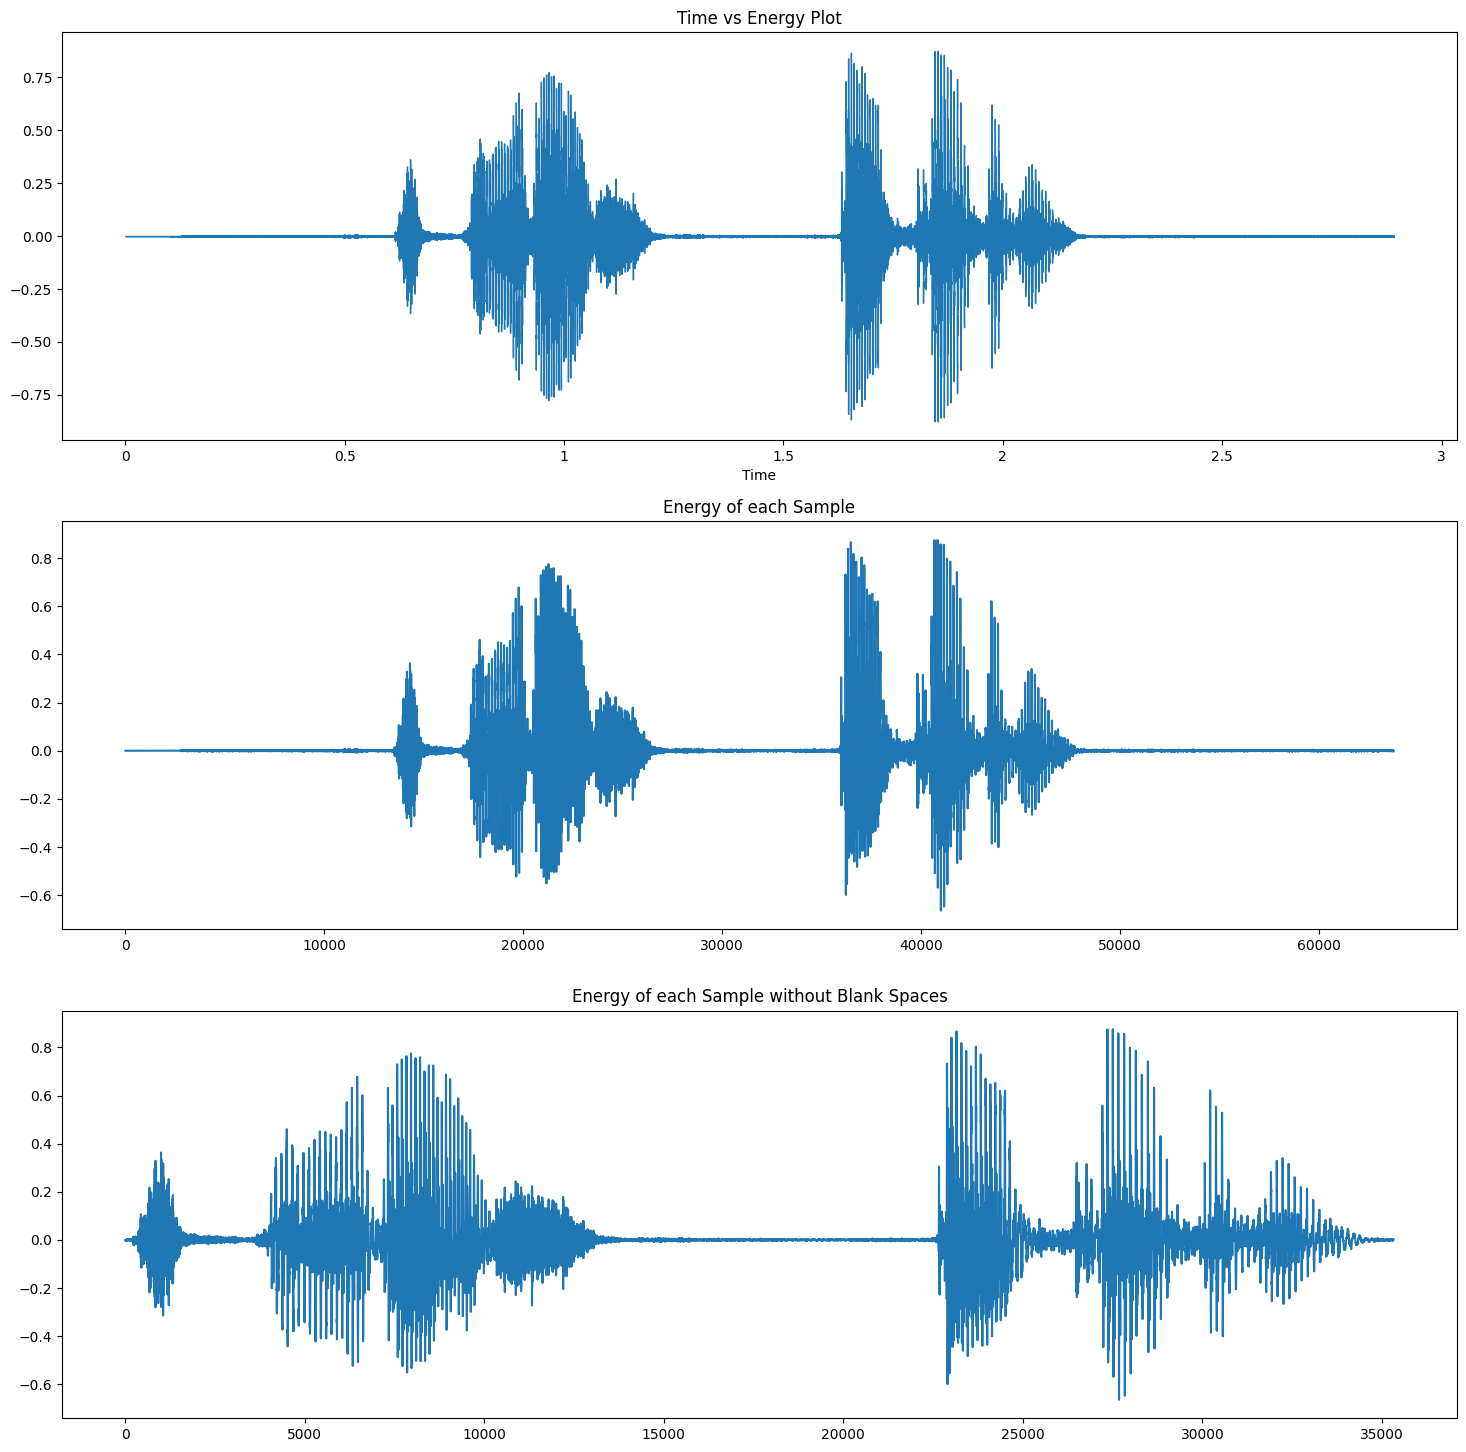

In [172]:
plt.figure(figsize=(18, 18))

plt.subplot(3, 1, 1)
librosa.display.waveshow(name_signal)
plt.title("Time vs Energy Plot")

plt.subplot(3, 1, 2)
pd.Series(name_signal).plot()
plt.title("Energy of each Sample")

plt.subplot(3, 1, 3)
name_trimmed, _ = librosa.effects.trim(name_signal, top_db=25)
pd.Series(name_trimmed).plot()
plt.title("Energy of each Sample without Blank Spaces")

plt.show()

In [173]:
# This function creates the spectogram using 2 functions (librosa.amplitude_to_db() and librosa.power_to_db())
def create_spectogram(signal, n_fft, hop_length, win_length, win_type):
    D = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=win_type)
    S_amp_db = librosa.amplitude_to_db(S=np.abs(D), ref=np.max)
    S_pow_db = librosa.power_to_db(np.abs(D)**2)
    return D, S_amp_db, S_pow_db

# This function creates the plots of the spectograms
def plot_spectogram(amp_signal, pow_signal, title):
    plt.figure(figsize=(16, 5))
    plt.suptitle(title)

    plt.subplot(1, 2, 1)
    librosa.display.specshow(amp_signal, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')

    plt.subplot(1, 2, 2)
    librosa.display.specshow(pow_signal, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')

    plt.show()
    

In [174]:
# Spectogram using a Hamming window with duration of 10msec
D10_msec, S10_msec_amp, S10_msec_pow = create_spectogram(name_signal, 256, 80, 160, "hamming")

# Spectogram using a Hamming window with duration of 100msec
D100_msec, S100_msec_amp, S100_msec_pow = create_spectogram(name_signal, 2048, 80, 1600, "hamming")

In [175]:
print(S10_msec_amp.shape)
print(S100_msec_amp.shape)

(129, 797)
(1025, 797)


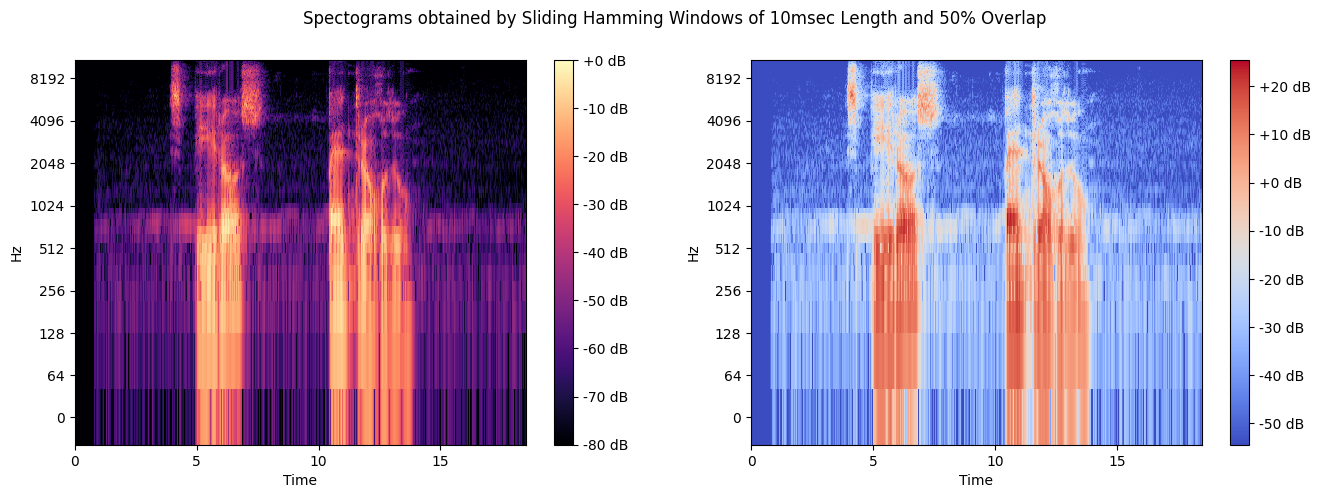

In [176]:
# Plot both spectograms for the Hamming window with duration of 10msec
plot_spectogram(S10_msec_amp, S10_msec_pow, "Spectograms obtained by Sliding Hamming Windows of 10msec Length and 50% Overlap")

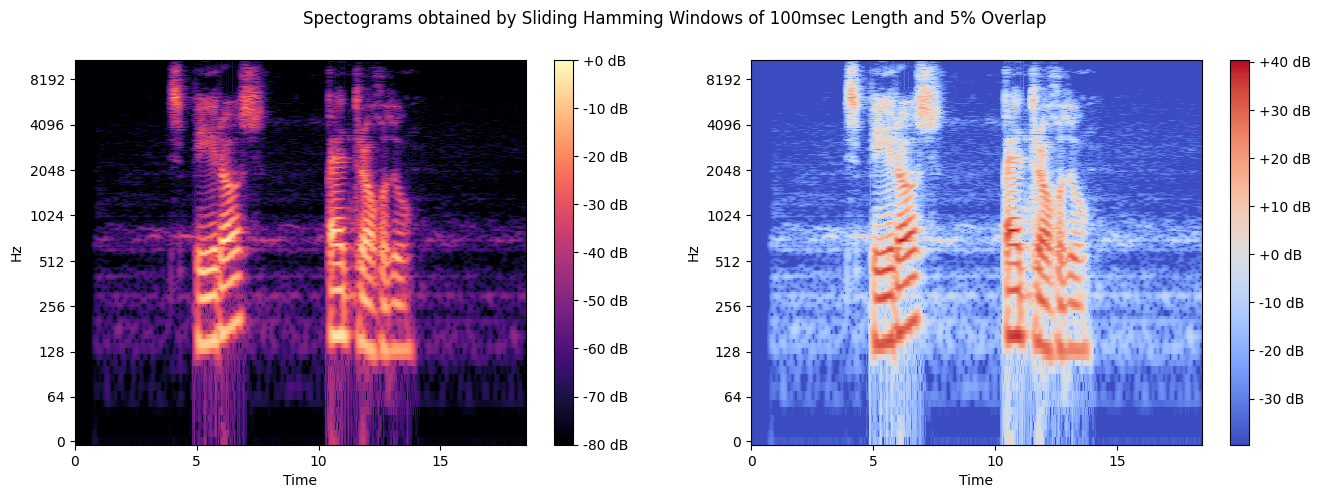

In [177]:
# Plot both spectograms for the Hamming window with duration of 10msec
plot_spectogram(S100_msec_amp, S100_msec_pow, "Spectograms obtained by Sliding Hamming Windows of 100msec Length and 5% Overlap")

In [400]:
# Apply short-time Energy in each frame using the sliding window technique
# The window size will be 2048 and the hop length will be 64 and I will use the Hamming window

FRAME_LENGTH = 400
HOP_LENGTH = 100

# Create the frames and store them in an array
frames = librosa.util.frame(name_signal, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)

# Create the window and apply it to each frame
hamming_window = np.hamming(FRAME_LENGTH)
windowed_frames = np.zeros((frames.shape[0], frames.shape[1]))

for i in range(frames.shape[1]):
    windowed_frames[:, i] = frames[:, i] * hamming_window
    
name_energy = np.sum(windowed_frames**2, axis=0)

print(f"Name Energy: {name_energy[30:35]}")
print(f"Shape of Name Energy: {name_energy.shape}")

# These will be useful for our plot

# x-axis -> number of frame
frame_num = np.linspace(1, name_energy.shape[0], name_energy.shape[0])

# y-axis -> short time energy in db, with max value 0
tol = 10**(-5) # Just to avoid log(0)
positive_name_energy = tol + name_energy
log_name_energy = 10 * np.log10(positive_name_energy)
print(f"Name Energy with tol: {positive_name_energy[30:35]}")

max_log_value = np.max(log_name_energy)
log_name_energy_db = log_name_energy - max_log_value
print(f"Max Log Value: {max_log_value}")
print(f"Name Energy in dB: {log_name_energy_db[30:35]}")
print(f"This MUST be zero: {np.max(log_name_energy_db)}")

Name Energy: [0.00024145 0.0002094  0.00020028 0.00020168 0.00023488]
Shape of Name Energy: (634,)
Name Energy with tol: [0.00025145 0.0002194  0.00021028 0.00021168 0.00024488]
Max Log Value: 11.628552844505418
Name Energy in dB: [-47.62396084 -48.21614418 -48.40057479 -48.37185157 -47.73910366]
This MUST be zero: 0.0


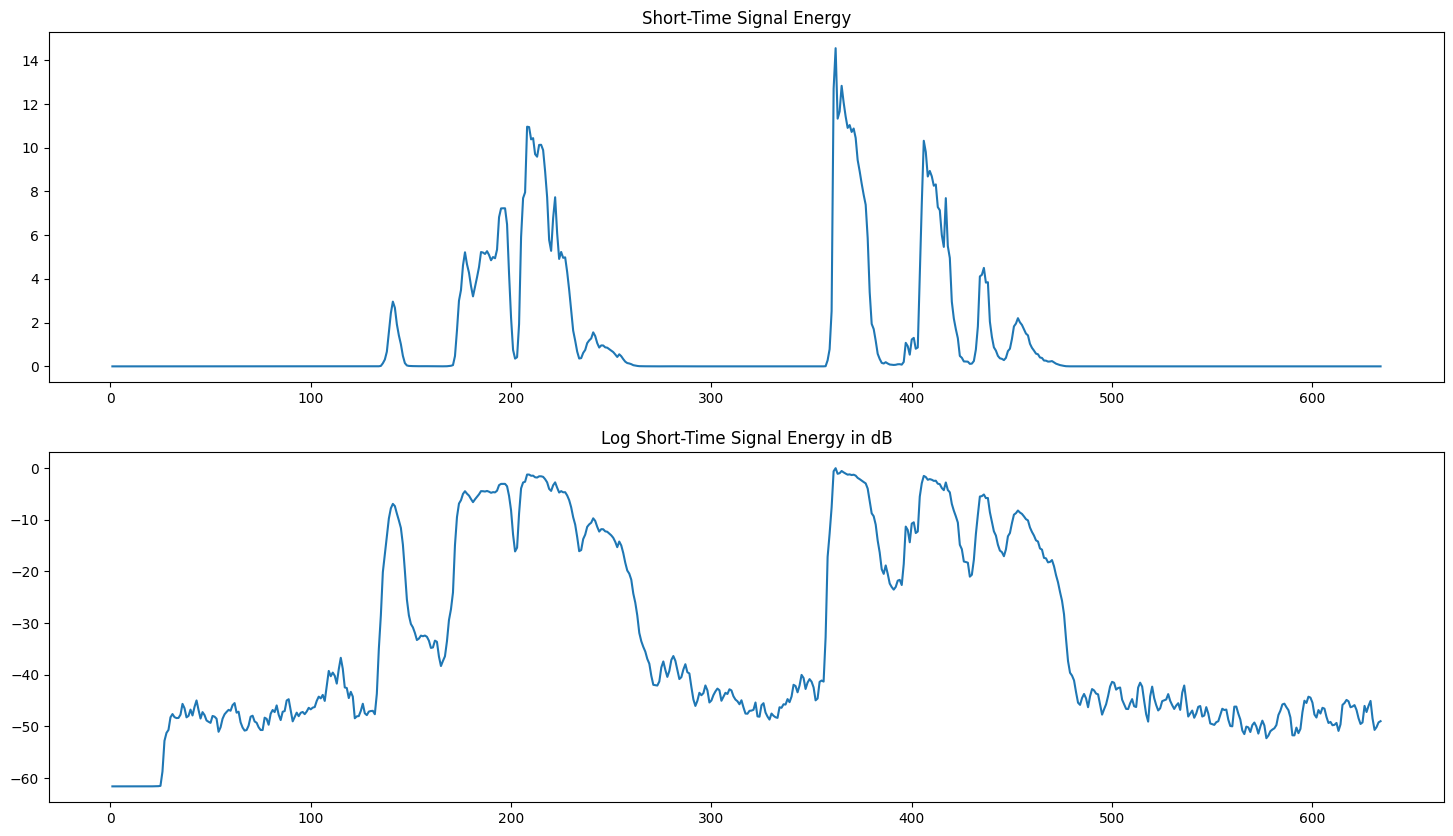

In [401]:
# Create a plot which will show us the short-time energy in each frame

plt.figure(figsize=(18, 10))

plt.subplot(2, 1, 1)
plt.plot(frame_num, name_energy)
plt.title("Short-Time Signal Energy")

plt.subplot(2, 1, 2)
plt.plot(frame_num, log_name_energy_db)
plt.title("Log Short-Time Signal Energy in dB")

plt.show()


In [443]:
# Now it's time to apply short-time zero crossing rate using the sliding window technique
# I will use the same frame characteristics as in short time energy computation, but with a rectangular window

FRAME_LENGTH_ZC = 2048
HOP_LENGTH_ZC = 64

frames = librosa.util.frame(name_signal, frame_length=FRAME_LENGTH_ZC, hop_length=HOP_LENGTH_ZC)
print(frames.shape)

name_zc = np.zeros(frames.shape[1])
print(name_zc.shape)

for i in range(frames.shape[1]):
   name_zc[i] = np.sum(librosa.zero_crossings(frames[:, i]))
   #name_zc[i] = int(name_zc[i] * HOP_LENGTH_ZC / (2*FRAME_LENGTH_ZC))
   
name_zc = name_zc * HOP_LENGTH_ZC / (2*FRAME_LENGTH_ZC)
   
print(name_zc[0:30])
print(name_zc.shape)

frame_num_zc = np.linspace(1, name_zc.shape[0], name_zc.shape[0])


(2048, 965)
(965,)
[0.015625 0.015625 0.015625 0.015625 0.125    0.25     0.484375 0.5625
 0.5625   0.625    0.6875   0.78125  0.9375   1.       1.109375 1.171875
 1.296875 1.390625 1.5      1.5625   1.640625 1.75     1.859375 1.921875
 2.09375  2.21875  2.3125   2.375    2.453125 2.609375]
(965,)


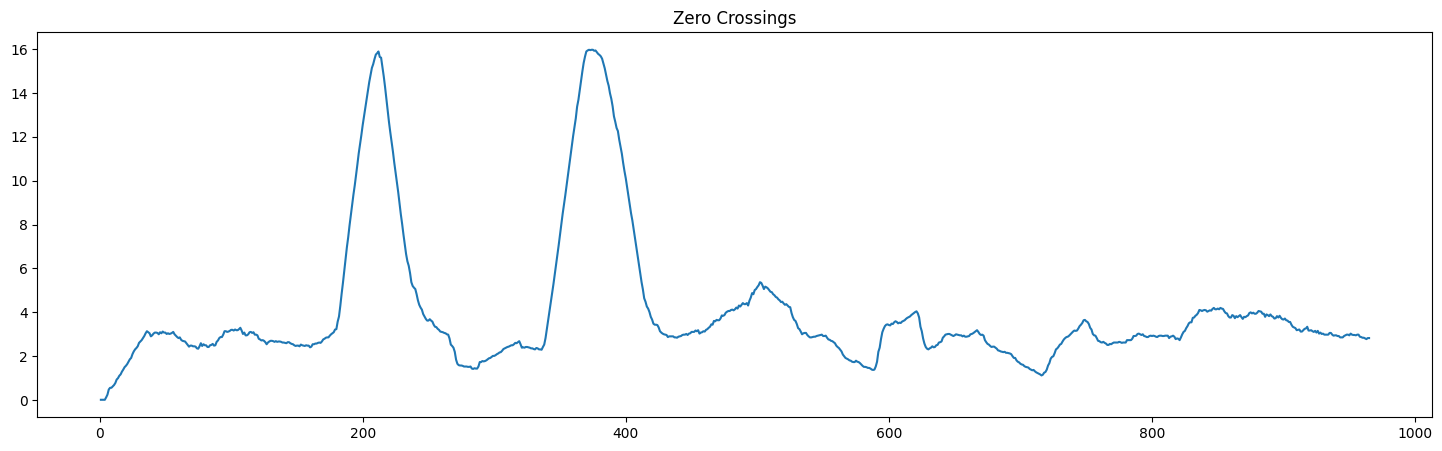

In [444]:
plt.figure(figsize=(18, 5))

plt.plot(frame_num_zc, name_zc)
plt.title("Zero Crossings")

plt.show()

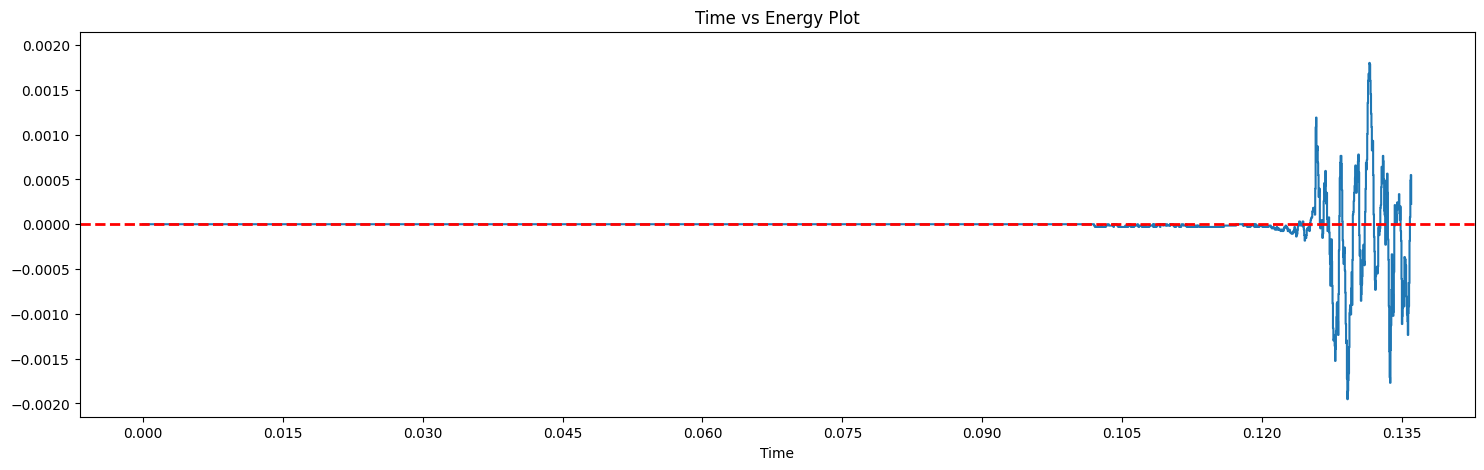

In [446]:
#print(name_signal[2200:2300])
plt.figure(figsize=(18,5))
librosa.display.waveshow(name_signal[0:3000])
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title("Time vs Energy Plot")
plt.show()

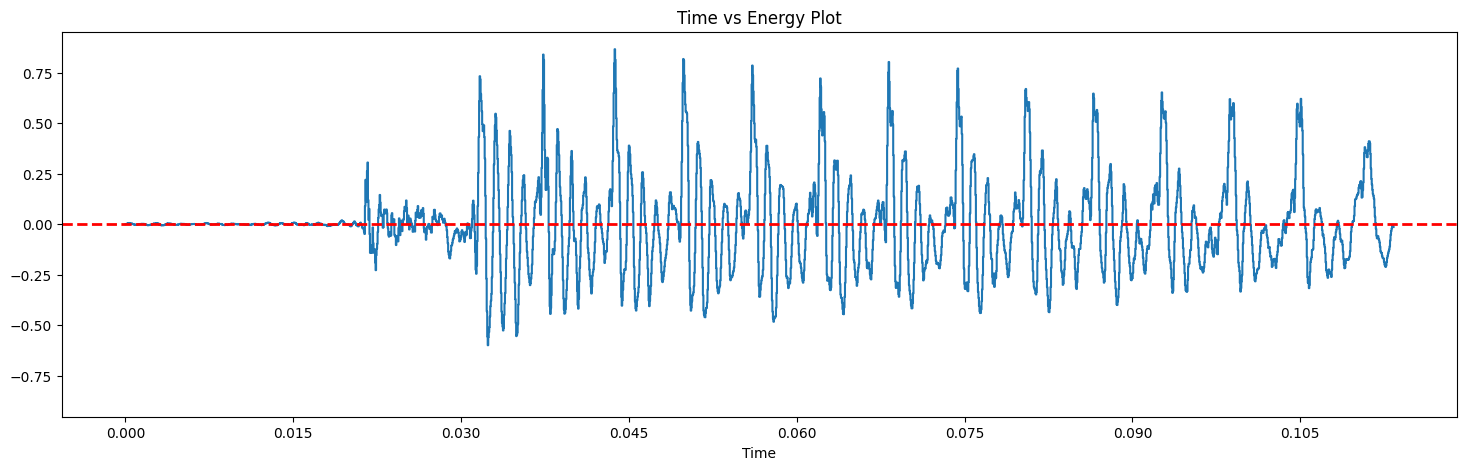

In [455]:
plt.figure(figsize=(18,5))
librosa.display.waveshow(name_signal[35500:38000])
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.title("Time vs Energy Plot")
plt.show()